In [1]:
# features
# - TEMA
# - EMA4, 9, 18 crossover
# - False Breakout Finder (*new intraday high, close lower than previous high, new intraday low, close higher than previous low
# - ATR
# - Relative Strength Analysis
# - market breadth (indicator of overall market performance)
# - skdj

import pandas as pd
import numpy as np
from itertools import combinations
import ta
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix

# Import price volume data

In [6]:
# def download_data(ticker: str):
#     df = yf.download(ticker, period="10y", interval="1d", multi_level_index=False)
#     df.dropna(inplace=True)
#     return df

def calculate_indicators(df, close, high, low, vol):
    df['RSI'] = ta.momentum.RSIIndicator(df[close]).rsi()

    macd = ta.trend.MACD(df[close])
    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    df['MACD_Hist'] = macd.macd_diff()

    df['ATR'] = ta.volatility.AverageTrueRange(df[high], df[low], df[close]).average_true_range()

    df['TEMA'] = ta.trend.EMAIndicator(df[close], window=30).ema_indicator()
    df['EMA4'] = ta.trend.EMAIndicator(df[close], window=4).ema_indicator()
    df['EMA9'] = ta.trend.EMAIndicator(df[close], window=9).ema_indicator()
    df['EMA18'] = ta.trend.EMAIndicator(df[close], window=18).ema_indicator()

    df['OBV'] = ta.volume.OnBalanceVolumeIndicator(df[close], df[vol], fillna=True).on_balance_volume()
    df['VWAP'] = ta.volume.VolumeWeightedAveragePrice(df[high], df[low], df[close], df[vol], fillna=True).volume_weighted_average_price()
    # df['EMA4_Crossover_up'] = (df['EMA4'] > df['EMA9']) & (df['EMA9'] > df['EMA18'])
    # df['EMA4_Crossover_down'] = (df['EMA4'] < df['EMA9']) & (df['EMA9'] < df['EMA18'])

    stoch = ta.momentum.StochasticOscillator(df[high], df[low], df[close])
    df['SKDJ_K'] = stoch.stoch()
    df['SKDJ_D'] = stoch.stoch_signal()

    return df

def calculate_flags(df, high, low, close):
    delta = 0.007
    df['Max_High'] = df[high].rolling(window=12).max().shift(-12)
    df['Min_Low'] = df[low].rolling(window=12).min().shift(-12)
    df['Flag'] = df.apply(lambda row:  2 if (row['Max_High'] > (1+delta)*row[close] and row['Min_Low'] < (1-delta)*row[close])
                                        else ((1 if row['Max_High'] > (1+delta)*row[close]
                                        else (-1 if row['Min_Low'] < (1-delta)*row[close]
                                        else 0))), axis=1)
    return df

def get_all_ratios(df, exclusion_list):
    feature_list = [col for col in df.columns.tolist() if col not in exclusion_list]
    new_columns = []
    for feat1, feat2 in combinations(feature_list, 2):
        column_name = f"{feat1}/{feat2}"
        new_columns.append((column_name, df[feat1] / df[feat2]))

    new_columns_df = pd.DataFrame(dict(new_columns))
    df = pd.concat([df, new_columns_df], axis=1)
    return df

def get_past_daily_ret(df, close):
    past_prices = []
    for i in range(0,30):
        column_name = f"Return_{i}"
        past_prices.append((column_name, df[close].shift(i)/df[close].shift(i+1)-1))
    past_prices_df = pd.DataFrame(dict(past_prices))
    df = pd.concat([df, past_prices_df], axis=1)
    return df

def get_past_daily_prices(df, close, n=100):
    past_prices = []
    for i in range(0,n):
        column_name = f"Price_{i}"
        past_prices.append((column_name, df[close].shift(i)))
    past_prices_df = pd.DataFrame(dict(past_prices))
    df = pd.concat([df, past_prices_df], axis=1)
    return df

def get_volume_profile(df, df_tick):
    # Parameters
    coverages = [0.6,0.7]
    windows = {
        'H1': '1h',
        'D1': '1D',
        'W1': '7D'
    }

    # Compute metrics
    for cov in coverages:
        for label, win in windows.items():
            profile_data = []
            time_index = []

            # Resample to every tick (or 1min for speed if needed)
            for current_time in df.index:
                window_start = current_time - pd.Timedelta(win)
                window_data = df_tick.loc[window_start:current_time - pd.Timedelta(milliseconds = 100)]

                if len(window_data) == 0:
                    profile_data.append([np.nan, np.nan, np.nan])
                else:
                    profile_data.append(volume_profile_summary(window_data['MID'], window_data['volume'], coverage=cov))
                time_index.append(current_time)

            profile_df = pd.DataFrame(profile_data, index=time_index,
                                      columns=[f'poc_{cov}_{label}', f'low_{cov}__{label}', f'high_{cov}__{label}'])
            df = df.join(profile_df)

    # Finalize
    return df

def volume_profile_summary(prices, volumes, coverage=0.7):
    # Create a Series of volumes with prices as the index
    vol_by_price = pd.Series(volumes.values, index=prices.values).groupby(level=0).sum()
    vol_by_price = vol_by_price.sort_index() #sorts in ascending order

    # Get the Point of Control (POC), which is the price with the highest volume
    poc = vol_by_price.idxmax()
    index = vol_by_price.values.argmax()
    total_vol = vol_by_price.sum()
    count = vol_by_price.count()

    # Initialize variables to track the expanding price range and covered volume
    price_low_pos = index
    price_high_pos = index
    volume_in_range = vol_by_price.iloc[index] # volume at poc

    # Expand in both directions equally initially
    while volume_in_range < total_vol * coverage:

        if price_low_pos-1 < 0 and price_high_pos+1 > count-1:
            break
        elif price_low_pos-1 < 0:
            price_high_pos += 1
            volume_in_range += vol_by_price.iloc[price_high_pos]
        elif price_high_pos+1 > count-1:
            price_low_pos -= 1
            volume_in_range += vol_by_price.iloc[price_low_pos]
        else:
            price_high_pos += 1
            price_low_pos -= 1
            volume_in_range = volume_in_range +  vol_by_price.iloc[price_low_pos] +  vol_by_price.iloc[price_high_pos]

    # The range where the coverage condition is met
    x_low = vol_by_price.index[price_low_pos]
    x_high = vol_by_price.index[price_high_pos]

    return poc, x_low, x_high

# def calculate_relative_strength(df, market):
#     df_market = yf.download(market, period="10y", interval="1d", multi_level_index=False)['Close'].rename(market)
#     df['market_close'] = df.merge(df_market, how='left', left_index=True, right_index=True)[market]
#     df['relative_strength'] = df['Close']/df['market_close']
#     df['relative_strength_EMA_4'] = ta.trend.EMAIndicator(df['relative_strength'], window=4).ema_indicator()
#     df['relative_strength_EMA_9'] = ta.trend.EMAIndicator(df['relative_strength'], window=9).ema_indicator()
#     return df

# def data_prep(ticker, market):
#     df = download_data(ticker)
#     df = calculate_indicators(df)
#     df = calculate_flags(df)
#     df = calculate_relative_strength(df, market)
#     df.drop(columns=['Max_High_2w', 'Min_Low_2w'], inplace=True)  # Clean up unnecessary columns
#     df.dropna(inplace=True)

    # return df
    # df.to_csv(f'{ticker}_processed.csv')
    # print(f'Data saved to {ticker}_processed.csv')

In [8]:
# Read and process base data
df =  pd.read_csv('Data/AUDNZD/AUDNZD_H1_201401012300_202504010800.csv', delimiter='\t',engine='python')
# df_iron = pd.read_csv('Data/AUDNZD/PIORECRUSDM.csv')
df['Date'] = pd.to_datetime(df['<DATE>'], format='%Y.%m.%d')
df['datetime'] = pd.to_datetime(df['<DATE>'] + ' ' + df['<TIME>'], format='%Y.%m.%d %H:%M:%S')
df.set_index('datetime', inplace=True)
df['time'] = pd.to_datetime(df['<TIME>'], format='%H:%M:%S').dt.hour
df['Weekday_num'] = df['Date'].dt.weekday     # Monday=0, Sunday=6
df['Month_num'] = df['Date'].dt.month         # January=1, December=12

In [4]:
#read and process tick data
df_tick = pd.read_parquet("Data/AUDNZD/AUDNZD_ticks_201401012300_202504010800.parquet")
df_tick_bid_ask = df_tick[df_tick['<FLAGS>'].isin([2,4,6])]
# tidy up data by using forward fill
df_tick_bid_ask.loc[:, '<BID>'] = df_tick_bid_ask['<BID>'].ffill()
df_tick_bid_ask.loc[:, '<ASK>'] = df_tick_bid_ask['<ASK>'].ffill()
df_tick_bid_ask.loc[:, 'MID'] = (df_tick_bid_ask['<BID>'] + df_tick_bid_ask['<ASK>'])/2
df_tick_bid_ask.loc[:, 'MID'] = df_tick_bid_ask['MID'].round(5)

# Assume df_tick_bid_ask has 'datetime' and 'mid' columns
df_ba = df_tick_bid_ask.copy()
df_ba['datetime'] = pd.to_datetime(df_ba['<DATE>'] + ' ' + df_ba['<TIME>'], format='%Y.%m.%d %H:%M:%S.%f')
df_ba = df_ba.sort_values('datetime').set_index('datetime')
# Simulated tick volume = 1 per row
df_ba['volume'] = 1
df_ba = df_ba[~df_ba.index.duplicated(keep='first')]

print(df_ba.index.min(), df_ba.index.max())

C:\Users\joeytian\AppData\Local\Temp\ipykernel_29496\2162206509.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tick_bid_ask.loc[:, 'MID'] = (df_tick_bid_ask['<BID>'] + df_tick_bid_ask['<ASK>'])/2


2014-01-01 23:00:51 2025-03-31 23:59:59.564000


In [9]:
# get indicators
df = calculate_indicators(df, '<CLOSE>', '<HIGH>', '<LOW>', '<TICKVOL>')
df = get_volume_profile(df, df_ba)
df = get_past_daily_prices(df, '<CLOSE>')
df = get_all_ratios(df, ['<DATE>','time','<TIME>','datetime','Date','<VOL>','Weekday_num','Month_num'])
# df = get_past_daily_ret(df, '<CLOSE>')
df = calculate_flags(df,'<HIGH>','<LOW>','<CLOSE>')


In [10]:
df.to_parquet(("Data/AUDNZD/AUDNZD_final_WPA_dataset_master.parquet"))

In [11]:
df['Flag'].value_counts()

Flag
 0    66279
-1     1840
 1     1803
 2       29
Name: count, dtype: int64

In [89]:
df.to_parquet(("Data/AUDNZD/AUDNZD_final_WPA_dataset.parquet"))

# Multiclass Catboost

In [12]:
# Sort data by Date
#multiclass catboost
df = df[df['Flag'].isin([-1, 0, 1])]
df = df.sort_index()

# Split the data into train and test (20% test data)
# Define train-test split with a gap of 20 data points
train_size = int(0.7 * len(df))
train_data = df.iloc[:train_size].replace([np.inf, -np.inf], np.nan).dropna()
test_data = df.iloc[train_size + 100:].replace([np.inf, -np.inf], np.nan).dropna()  # Skipping 20 rows

# Features (excluding 'Date' and 'Flag' columns)
exclusion_list = ['datetime','<TIME>','Date','<DATE>','<VOL>','Flag','Max_High','Min_Low']
features = [col for col in df.columns.tolist() if col not in exclusion_list]

X_train = train_data[features]
y_train = train_data['Flag']

X_test = test_data[features]
y_test = test_data['Flag']

# Initialize CatBoost model (silent mode)
cb = CatBoostClassifier(verbose=False, random_state=42, task_type = "GPU")

# Hyperparameter space
param_dist = {'depth'         : [4,8,10,12],
              'learning_rate' : [0.05, 0.1],
              'iterations'    : [500, 1000]
              }

# Set number of splits (e.g., 3)
cv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_dist,
    scoring='roc_auc',
    cv=cv,
    n_iter=20,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the model
search.fit(X_train, y_train)

best_cb = search.best_estimator_
print(f"Best Params: {search.best_params_}")

y_pred = best_cb.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

import joblib
joblib.dump(best_cb, 'model_multiclass.joblib')

C:\Users\joeytian\anaconda3\envs\algo\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 16 candidates, totalling 48 fits


KeyboardInterrupt: 

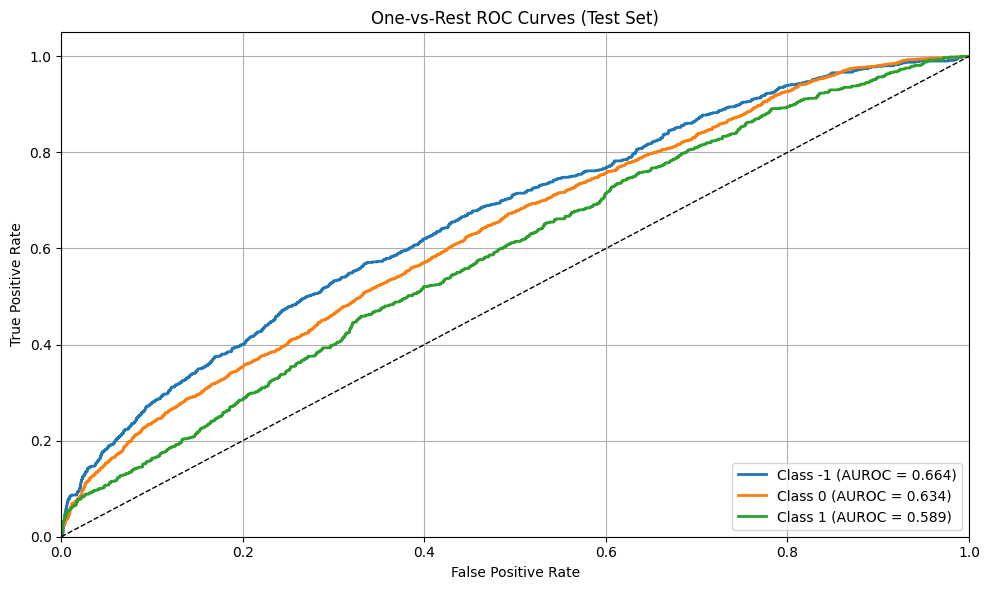

In [24]:
# Use your fitted model and predictions
y_test_pred_proba = best_cb.predict_proba(X_test)
classes = best_cb.classes_
y_test_bin = label_binarize(y_test, classes=classes)

# Plot setup
plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {cls} (AUROC = {roc_auc:.3f})')

# Chance line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

# Labels & styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [57]:
result

,0,1,2,3
0,0.0,0.022197,0.953921,0.023882
1,0.0,0.019231,0.957677,0.023092
2,0.0,0.024168,0.954515,0.021318
3,0.0,0.021699,0.961586,0.016715
4,0.0,0.023662,0.960788,0.015550
...,...,...,...,...
20433,0.0,0.043074,0.927011,0.029915
20434,0.0,0.039083,0.928997,0.031920
20435,0.0,0.042091,0.928700,0.029209
20436,0.0,0.039012,0.931779,0.029209


In [73]:
result = pd.DataFrame(np.concatenate((y_test.to_numpy().reshape(-1,1), y_test_pred_proba), axis=1), columns=['Flag', 'bear', 'neutral', 'long'])
filtered_rows = result[(result['bear']>result['neutral']) | (result['long']>result['neutral'])]
high_prob = filtered_rows[(filtered_rows['bear']>0.6)]

high_prob['Flag'].value_counts(normalize=True)

Flag
 0.0    0.554839
-1.0    0.316129
 1.0    0.129032
Name: proportion, dtype: float64

In [51]:
y_test.shape

(20438,)

In [69]:
## TEST
coverage = 0.7
increment = 0.1
prices = [10, 11, 11.1, 11.5, 11.6, 11.8, 12, 12.1]
volumes = [1,1,3,5,6,5,4,3] #20

# Create a Series of volumes with prices as the index
vol_by_price = pd.Series(volumes, index=prices).groupby(level=0).sum()
vol_by_price = vol_by_price.sort_index() #sorts in ascending order

# Get the Point of Control (POC), which is the price with the highest volume
poc = vol_by_price.idxmax()
index = vol_by_price.values.argmax()
total_vol = vol_by_price.sum()
count = vol_by_price.count()

# Initialize variables to track the expanding price range and covered volume
price_low_pos = index
price_high_pos = index
volume_in_range = vol_by_price.iloc[index] # volume at poc

# Expand in both directions equally initially
while volume_in_range < total_vol * coverage:
    if price_low_pos-1 < 0 and price_high_pos+1 > count-1:
        break
    elif price_low_pos-1 < 0:
        price_high_pos += 1
        volume_in_range += vol_by_price.iloc[price_high_pos]
    elif price_high_pos+1 > count-1:
        price_low_pos -= 1
        volume_in_range += vol_by_price.iloc[price_low_pos]
    else:
        price_high_pos += 1
        price_low_pos -= 1
        volume_in_range = volume_in_range +  vol_by_price.iloc[price_low_pos] +  vol_by_price.iloc[price_high_pos]

    print(price_low_pos, price_high_pos)
# The range where the coverage condition is met
x_low = vol_by_price.index[price_low_pos]
x_high = vol_by_price.index[price_high_pos]
print(x_low, poc, x_high)



3 5
2 6
11.1 11.6 12.0
